# Clustering

How the features were built is in `features.ipynb`. Why some columns stay out is in `analysis/columns.ipynb`, and the choice of k in `analysis/k.ipynb`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

from advisor.features import FEATURES

pd.set_option("display.width", 140)

df = pd.read_csv(Path("../data/processed/sleep_health.csv"))
df.shape

(374, 17)

## Features and scaling

In [2]:
df[FEATURES].describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
Age,42.18,8.67,27.00,59.00
Sleep Duration,7.13,0.80,5.80,8.50
Quality of Sleep,7.31,1.20,4.00,9.00
Activity Index,-0.00,0.94,-1.88,1.72
Stress Level,5.39,1.77,3.00,8.00
Heart Rate,70.17,4.14,65.00,86.00
Mean Arterial Pressure,99.28,6.65,88.33,110.00
BMI,0.45,0.55,0.00,2.00


In [3]:
scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES])
X.shape

(374, 8)

## Choosing k

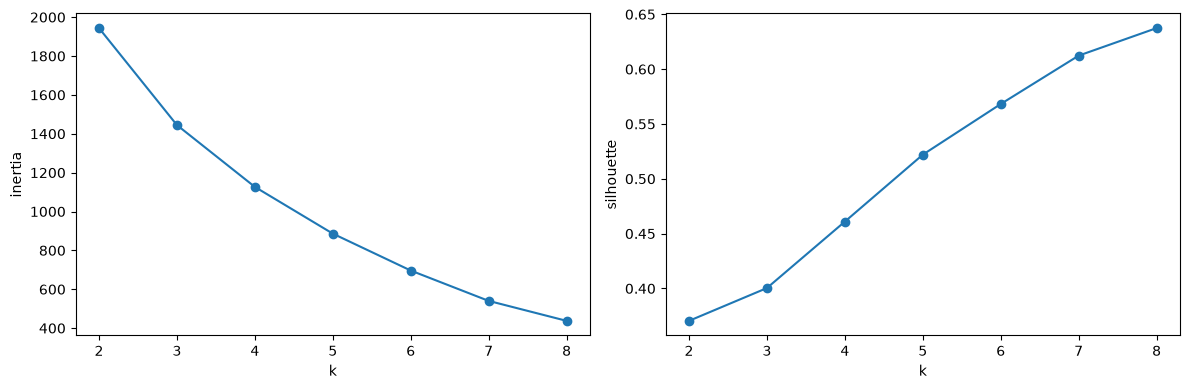

In [4]:
ks = range(2, 9)
inertia = []
silhouette = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=200).fit(X)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X, model.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ks, inertia, marker="o")
ax1.set_xlabel("k")
ax1.set_ylabel("inertia")
ax2.plot(ks, silhouette, marker="o")
ax2.set_xlabel("k")
ax2.set_ylabel("silhouette")
plt.tight_layout()
Path("../figures").mkdir(exist_ok=True)
fig.savefig("../figures/elbow_silhouette.png", dpi=120, bbox_inches="tight")

No clear elbow. Silhouette has a first peak at k = 5, dips at 6 and then keeps rising: with values on a grid, more clusters can always isolate more grid points. Neither gives a clear answer, and stability across resamples does not either: with enough restarts every k from 3 to 8 is stable. I pick 5 for use: each cluster becomes a short written profile for a language model, five are easier to keep apart in words than seven, and the silhouette has its first peak there. The details, and what k = 7 would add, are in `analysis/k.ipynb`.

## Fit

`n_init=200` because with the default ten restarts only about one seed in three reaches the best partition; the others land on a solution that merges half of cluster 3 into cluster 0. With 200 restarts every seed I tried gives the same partition (`analysis/k.ipynb`).

In [5]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=200)
df["cluster"] = kmeans.fit_predict(X)
df["cluster"].value_counts().sort_index()

cluster
0    101
1     34
2    145
3     62
4     32
Name: count, dtype: int64

In [6]:
pd.DataFrame(
    {
        "people": df["cluster"].value_counts().sort_index(),
        "distinct rows": pd.DataFrame(X)
        .assign(cluster=df["cluster"])
        .drop_duplicates()
        .groupby("cluster")
        .size(),
    }
)

,people,distinct rows
cluster,,
0,101,36
1,34,9
2,145,39
3,62,14
4,32,8


Smallest cluster is 32 people. Behind the two smallest groups there are 8 and 9 distinct rows, repeated. More in `analysis/k.ipynb`.

## Profiles

In [7]:
original = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Stress Level",
    "Physical Activity Level",
    "Daily Steps",
    "Heart Rate",
    "Systolic",
    "Diastolic",
]
df.groupby("cluster")[original].mean().round(1)

,Age,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level,Daily Steps,Heart Rate,Systolic,Diastolic
cluster,,,,,,,,,
0,37.8,6.3,6.0,7.2,40.4,5504.0,73.8,128.5,83.7
1,53.0,8.4,9.0,3.0,33.5,5294.1,65.0,124.6,79.7
2,36.9,7.5,7.8,4.9,70.4,7566.9,68.9,123.0,80.8
3,51.8,7.4,8.1,3.5,61.8,6393.5,67.4,137.8,92.7
4,49.8,6.1,6.0,8.0,90.0,10000.0,75.0,140.0,95.0


Where each group stands against the whole data, in standard deviations of each column. This is what the written profiles are read from: values around zero are average, above 1 or below -1 stand out.

In [8]:
means = df.groupby("cluster")[original].mean()
((means - df[original].mean()) / df[original].std()).round(1)

,Age,Sleep Duration,Quality of Sleep,Stress Level,Physical Activity Level,Daily Steps,Heart Rate,Systolic,Diastolic
cluster,,,,,,,,,
0,-0.5,-1.0,-1.1,1.0,-0.9,-0.8,0.9,-0.0,-0.2
1,1.2,1.6,1.4,-1.3,-1.2,-0.9,-1.2,-0.5,-0.8
2,-0.6,0.4,0.4,-0.3,0.5,0.5,-0.3,-0.7,-0.6
3,1.1,0.4,0.7,-1.0,0.1,-0.3,-0.7,1.2,1.3
4,0.9,-1.3,-1.1,1.5,1.5,2.0,1.2,1.5,1.7


- 0: 101 people in their late thirties. Short and poor sleep, high stress, the least active group. About half overweight, the only group mixed on BMI.
- 1: 34 people in their early fifties, all normal BMI. The longest and best sleep and the lowest stress, with little activity.
- 2: the largest group, 145 people in their late thirties with normal BMI. They sleep well, are active and have the lowest blood pressure.
- 3: 62 people around 52, all overweight or obese. They sleep well and report low stress, but blood pressure is almost as high as in cluster 4.
- 4: 32 people around 50, all overweight and the most active. Shortest sleep, highest stress, highest blood pressure.

In [9]:
pd.crosstab(df["cluster"], df["BMI Category"])

BMI Category,Normal,Obese,Overweight
cluster,,,
0,38,8,55
1,34,0,0
2,144,0,1
3,0,2,60
4,0,0,32


## Checks

`Sleep Disorder` was not a feature.

In [10]:
pd.crosstab(df["cluster"], df["Sleep Disorder"])

Sleep Disorder,Insomnia,No disorder,Sleep Apnea
cluster,,,
0,45,43,13
1,1,33,0
2,5,136,4
3,25,5,32
4,1,2,29


Clusters 1 and 2 are almost all without a disorder. Cluster 0 holds most of the insomnia, clusters 3 and 4 most of the apnea. Cluster 3 has 57 people with a disorder out of 62, with sleep and stress close to the healthy clusters. The difference is in blood pressure and age.

In [11]:
pd.crosstab(df["cluster"], df["Gender"])

Gender,Female,Male
cluster,,
0,20,81
1,34,0
2,39,106
3,60,2
4,32,0


Clusters 1, 3 and 4 are almost all women, 0 and 2 mostly men. Gender is not a feature, see `analysis/columns.ipynb`.

## What I take from this

k = 5 is a choice for use more than a number the scores give: each cluster becomes a written profile for the guidance step, and five can be described and told apart (`analysis/k.ipynb`). The five differ on more than one axis. Sleep Disorder lines up with them to a modest degree, about as much as BMI alone does (`analysis/columns.ipynb`). Three groups are almost entirely women and two are a few repeated rows; both things go into the profiles as they are.